##Exploratory Data Analysis: Online Course Recommendation

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_excel('online_course_recommendation.xlsx')
print("Dataset shape:", df.shape)
df.head(5)

Dataset shape: (100000, 14)


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


##Check and Handle Missing Values

In [3]:
# Check for missing values in each column
print(df.isnull().sum())

user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64


##Descriptive Statistics

In [6]:
# Separate numerical and categorical columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Descriptive stats for numerical variables
print(df[numeric_cols].describe().T)

# Descriptive stats for categorical variables
print(df[categorical_cols].describe().T)

                           count          mean           std     min  \
user_id                 100000.0  24935.663570  14406.960108   1.000   
course_id               100000.0   5006.863560   2882.085456   1.000   
course_duration_hours   100000.0     52.383540     27.423470   5.000   
rating                  100000.0      3.959859      0.729958   1.000   
enrollment_numbers      100000.0  25052.822850  14388.188356  50.000   
course_price            100000.0    261.073369    139.013758  20.000   
feedback_score          100000.0      0.746865      0.143683   0.092   
time_spent_hours        100000.0     20.691054     13.669148   1.000   
previous_courses_taken  100000.0      4.992670      2.237259   0.000   

                              25%       50%         75%       max  
user_id                 12487.750  24793.50  37382.2500  49999.00  
course_id                2523.000   5012.00   7502.0000   9999.00  
course_duration_hours      28.600     52.40     76.1000    100.00  
rating 

##Data Visualization

###Histograms of Numerical Variables

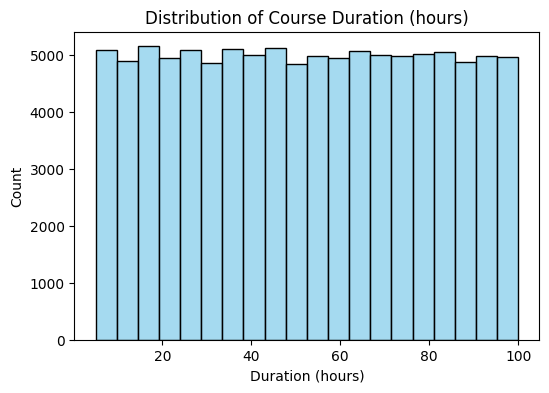

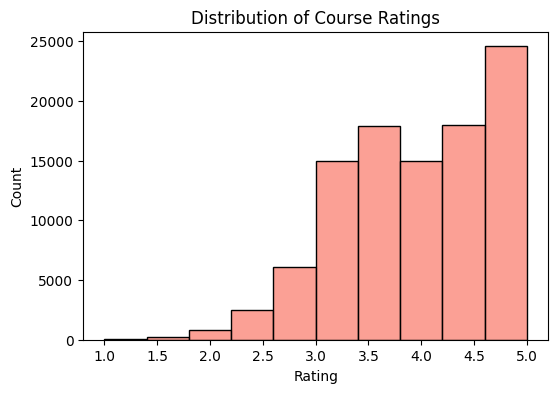

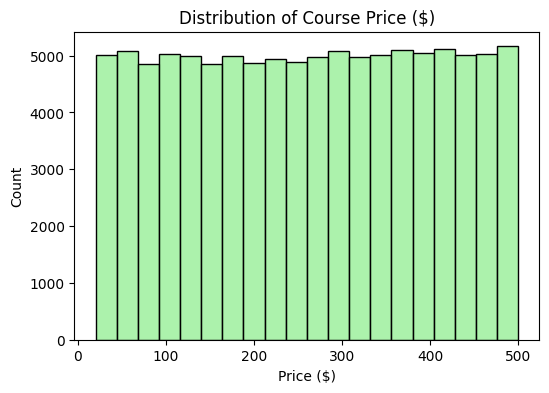

In [7]:
# Histogram of course duration
plt.figure(figsize=(6,4))
sns.histplot(df['course_duration_hours'], bins=20, color='skyblue')
plt.title("Distribution of Course Duration (hours)")
plt.xlabel("Duration (hours)")
plt.ylabel("Count")
plt.show()

# Histogram of course ratings
plt.figure(figsize=(6,4))
sns.histplot(df['rating'], bins=10, color='salmon')
plt.title("Distribution of Course Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Histogram of course prices
plt.figure(figsize=(6,4))
sns.histplot(df['course_price'], bins=20, color='lightgreen')
plt.title("Distribution of Course Price ($)")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

###Box Plots for Outliers

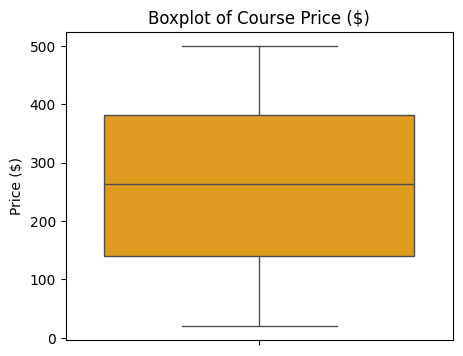

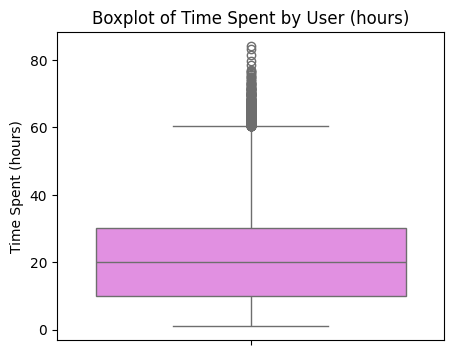

In [8]:
# Box plot of course price
plt.figure(figsize=(5,4))
sns.boxplot(y=df['course_price'], color='orange')
plt.title("Boxplot of Course Price ($)")
plt.ylabel("Price ($)")
plt.show()

# Box plot of time spent by user
plt.figure(figsize=(5,4))
sns.boxplot(y=df['time_spent_hours'], color='violet')
plt.title("Boxplot of Time Spent by User (hours)")
plt.ylabel("Time Spent (hours)")
plt.show()

###Bar Plots for Categorical Variables

/tmp/ipython-input-2368867823.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='difficulty_level', data=df,


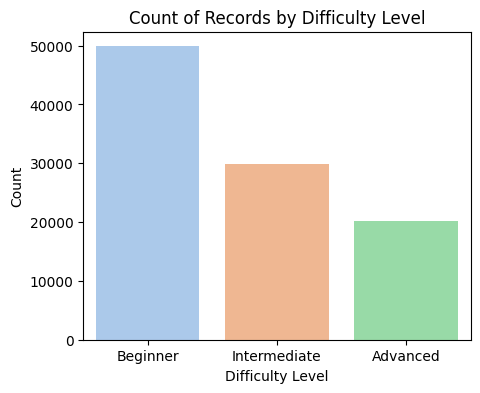

/tmp/ipython-input-2368867823.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='certification_offered', data=df, palette='pastel')


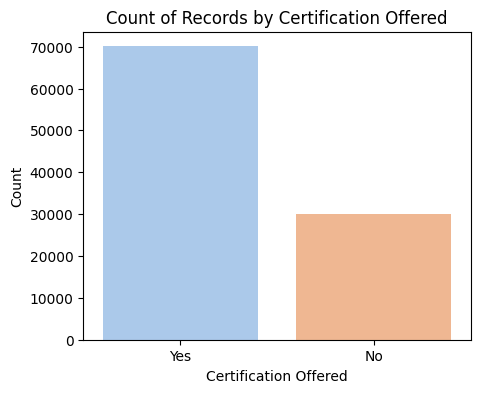

In [9]:
# Bar plot for difficulty levels
plt.figure(figsize=(5,4))
sns.countplot(x='difficulty_level', data=df,
              order=['Beginner','Intermediate','Advanced'],
              palette='pastel')
plt.title("Count of Records by Difficulty Level")
plt.xlabel("Difficulty Level")
plt.ylabel("Count")
plt.show()

# Bar plot for certification offered
plt.figure(figsize=(5,4))
sns.countplot(x='certification_offered', data=df, palette='pastel')
plt.title("Count of Records by Certification Offered")
plt.xlabel("Certification Offered")
plt.ylabel("Count")
plt.show()

###Correlation Heatmap

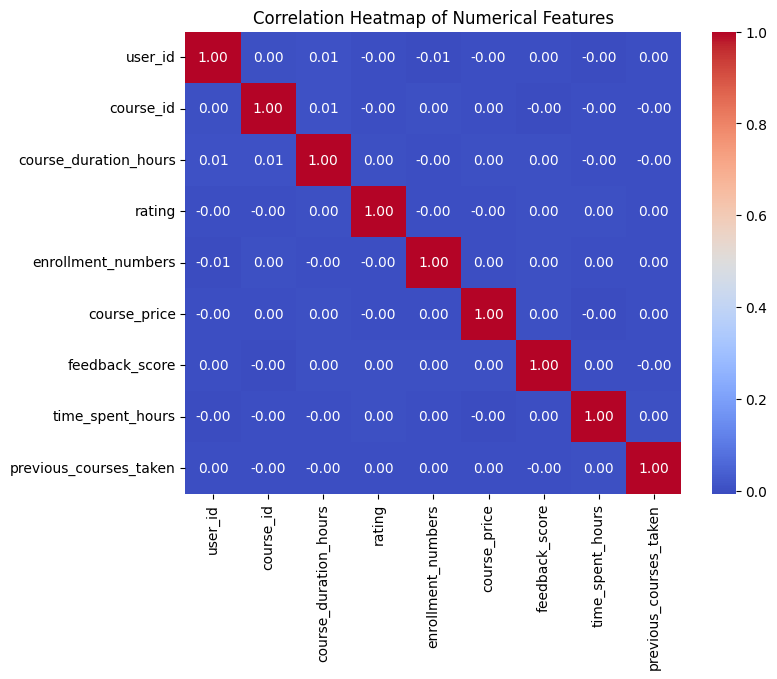

In [10]:
# Correlation heatmap of numerical features
num_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = num_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

###Most Popular Courses by Enrollment

/tmp/ipython-input-1422059052.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popular_courses.values, y=popular_courses.index, palette='viridis')


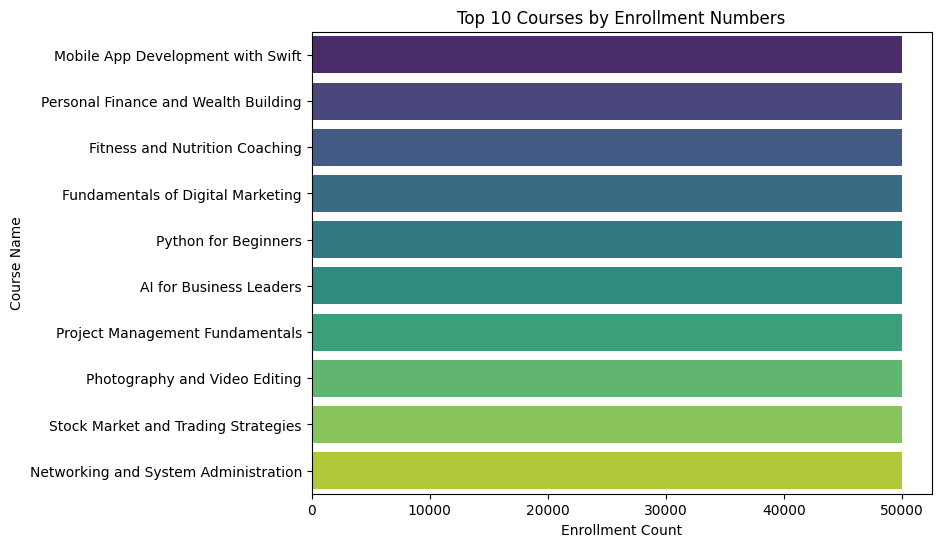

In [11]:
# Find top 10 courses by enrollment
popular_courses = df.groupby('course_name')['enrollment_numbers'] \
                    .max().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=popular_courses.values, y=popular_courses.index, palette='viridis')
plt.title("Top 10 Courses by Enrollment Numbers")
plt.xlabel("Enrollment Count")
plt.ylabel("Course Name")
plt.show()

###Instructor-wise Average Rating and Enrollments

/tmp/ipython-input-859233380.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='instructor', data=top_instructors, palette='magma', ax=axes[0])
/tmp/ipython-input-859233380.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='enrollment_numbers', y='instructor', data=top_instructors, palette='magma', ax=axes[1])


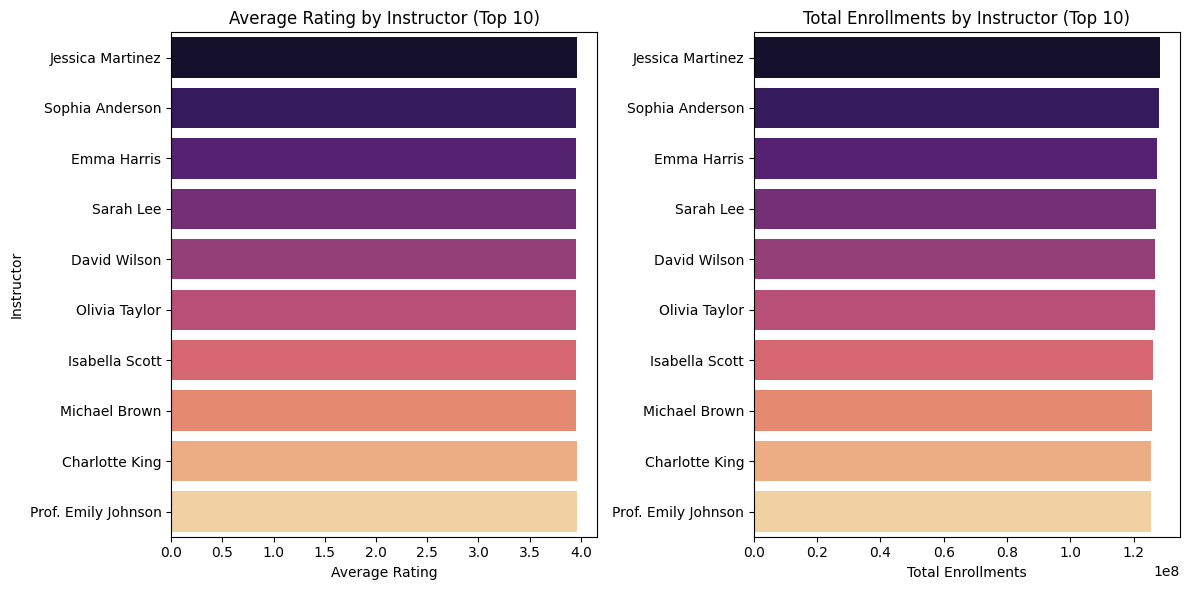

In [12]:
# Compute instructor-wise stats and select top 10 by enrollments
instr_stats = df.groupby('instructor').agg({'rating':'mean','enrollment_numbers':'sum'}) \
                .reset_index()
top_instructors = instr_stats.sort_values('enrollment_numbers', ascending=False).head(10)

# Plot average rating and total enrollment for top instructors
fig, axes = plt.subplots(1, 2, figsize=(12,6))
sns.barplot(x='rating', y='instructor', data=top_instructors, palette='magma', ax=axes[0])
axes[0].set_title("Average Rating by Instructor (Top 10)")
axes[0].set_xlabel("Average Rating")
axes[0].set_ylabel("Instructor")

sns.barplot(x='enrollment_numbers', y='instructor', data=top_instructors, palette='magma', ax=axes[1])
axes[1].set_title("Total Enrollments by Instructor (Top 10)")
axes[1].set_xlabel("Total Enrollments")
axes[1].set_ylabel("")  # shared y-axis labels
plt.tight_layout()
plt.show()

###Ratings and Enrollment by Certification Availability

/tmp/ipython-input-2485810735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='certification_offered', y='rating', data=df, palette='Set2', ax=axes[0])
/tmp/ipython-input-2485810735.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='certification_offered', y='enrollment_numbers', data=df, palette='Set2', ax=axes[1])


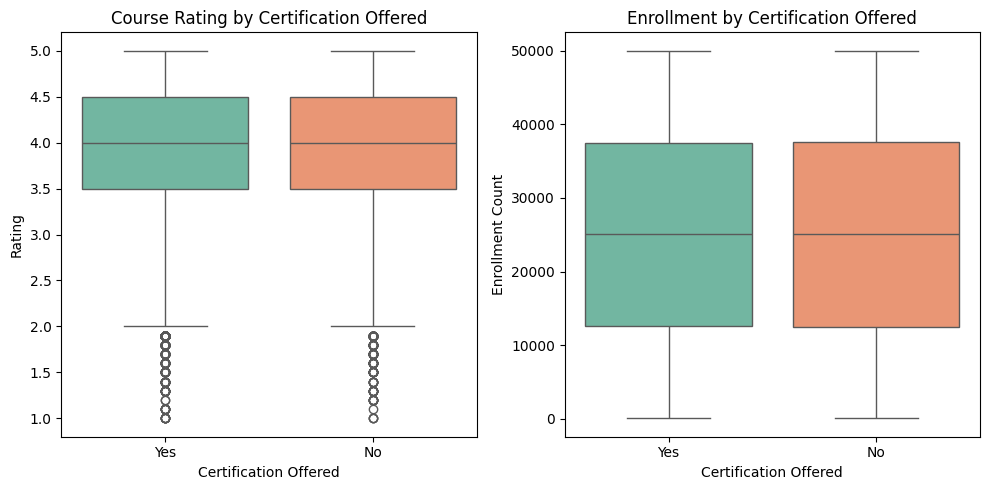

In [13]:
# Box plots of rating and enrollment by certification
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.boxplot(x='certification_offered', y='rating', data=df, palette='Set2', ax=axes[0])
axes[0].set_title("Course Rating by Certification Offered")
axes[0].set_xlabel("Certification Offered")
axes[0].set_ylabel("Rating")

sns.boxplot(x='certification_offered', y='enrollment_numbers', data=df, palette='Set2', ax=axes[1])
axes[1].set_title("Enrollment by Certification Offered")
axes[1].set_xlabel("Certification Offered")
axes[1].set_ylabel("Enrollment Count")
plt.tight_layout()
plt.show()